In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [3]:
data = pd.read_csv("./data/salary2.csv")
data.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


#### 분석목적: 학력, 교육연수, 혼인상태, 직업정보가 있는 연봉데이터셋을 이용해 연봉 예측하기
* 연봉이 5만달러 이상인지 아닌지
* age: 나이
* workclass: 고용형태
* education: 학력
* education-num: 교육연수
* marital-status: 혼인상태
* occupation: 직업
* relationship: 가족관계
* race: 인종
* sex: 성별
* capital-gain: 자산증가
* capital-loss: 자산감소
* hours-per-week: 주당 노동 시간
* native-country: 본국
* class: 연봉구분 - target(분석대상)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   education       48842 non-null  object
 3   education-num   48842 non-null  int64 
 4   marital-status  48842 non-null  object
 5   occupation      46033 non-null  object
 6   relationship    48842 non-null  object
 7   race            48842 non-null  object
 8   sex             48842 non-null  object
 9   capital-gain    48842 non-null  int64 
 10  capital-loss    48842 non-null  int64 
 11  hours-per-week  48842 non-null  int64 
 12  native-country  47985 non-null  object
 13  class           48842 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


In [6]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


# 결측값 탐색

In [7]:
data.isna().sum()

age                  0
workclass         2799
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

In [8]:
data.isna().sum() / len(data) * 100

age               0.000000
workclass         5.730724
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
class             0.000000
dtype: float64

In [10]:
data['class'].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [11]:
data[data['workclass'].isna()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [12]:
data[data['occupation'].isna()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [16]:
data[(data['workclass'].isna()) & (data['occupation'].isna()) & (data['class'] == " >50K")]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
89,41,NaN,Masters,14,Married-civ-spouse,NaN,Wife,White,Female,7688,0,10,United-States,>50K
182,28,NaN,HS-grad,9,Married-civ-spouse,NaN,Own-child,White,Female,0,0,38,United-States,>50K
274,53,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,>50K
505,38,NaN,HS-grad,9,Married-civ-spouse,NaN,Wife,White,Female,0,1887,10,United-States,>50K
781,62,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,5178,0,40,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48278,60,NaN,Some-college,10,Married-civ-spouse,NaN,Husband,White,Male,0,0,12,United-States,>50K
48279,52,NaN,12th,8,Married-civ-spouse,NaN,Wife,Black,Female,0,0,40,United-States,>50K
48297,62,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,>50K
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K


In [17]:
265 / 11687 *100

2.267476683494481

In [15]:
data['class'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [19]:
data.dropna()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [20]:
45222 / len(data) * 100

92.58834609557348

# 결측값의 비율이 약 7.5%이고 삭제시 데이터 분포에 편향을 주지 않으므로 삭제

In [22]:
data = data.dropna()
data = data.reset_index(drop=True)
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [24]:
data['class'] = data['class'].apply(lambda x: 1 if x == ' >50K' else 0)
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


# 이상치 탐색

In [25]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week,class
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017,0.247844
std,13.217870,2.552881,7506.430084,404.956092,12.007508,0.431766
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [26]:
data['capital-gain'].value_counts()

capital-gain
0        41432
15024      498
7688       391
7298       351
99999      229
         ...  
7262         1
1731         1
22040        1
1639         1
2387         1
Name: count, Length: 121, dtype: int64

<Axes: ylabel='Frequency'>

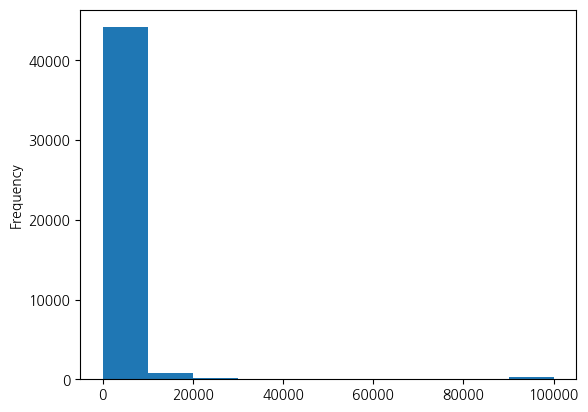

In [27]:
data['capital-gain'].plot(kind="hist")

이상값이 없음

# EDA

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education       45222 non-null  object
 3   education-num   45222 non-null  int64 
 4   marital-status  45222 non-null  object
 5   occupation      45222 non-null  object
 6   relationship    45222 non-null  object
 7   race            45222 non-null  object
 8   sex             45222 non-null  object
 9   capital-gain    45222 non-null  int64 
 10  capital-loss    45222 non-null  int64 
 11  hours-per-week  45222 non-null  int64 
 12  native-country  45222 non-null  object
 13  class           45222 non-null  int64 
dtypes: int64(6), object(8)
memory usage: 4.8+ MB


In [29]:
obj_cols = data.select_dtypes(include='object')
num_cols = data.select_dtypes(exclude='object')

In [46]:
ratio_result = data[['education', 'class']].groupby('education').mean().sort_values(by='class', ascending=False)
ratio_result[ratio_result['class'] > 0.40].index

Index([' Prof-school', ' Doctorate', ' Masters', ' Bachelors'], dtype='object', name='education')

In [47]:
important_cols = []
for col in obj_cols:
    print("=" * 30, col, "=" * 30)
    print(col, f"nunique {obj_cols[col].nunique()}")
    print()
    print(obj_cols[col].value_counts())
    print()
    print(data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    ratio_result = data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False)
    ratio_result = data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False)
    important_cols.append(ratio_result[ratio_result['class'] > 0.40].index)
    print()

============================== workclass ==============================
workclass nunique 7

workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64

                     class
workclass                 
Self-emp-inc      0.554070
Federal-gov       0.390469
Local-gov         0.295161
Self-emp-not-inc  0.278978
State-gov         0.267215
Private           0.217702
Without-pay       0.095238

============================== education ==============================
education nunique 16

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool 

workclass 1
education 4
marital-status 2
occupation 2
relationship 2
native-country 3


['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'native-country']

# 수치형 변수들 EDA

,age,education-num,capital-gain,capital-loss,hours-per-week
0,25,7,0,0,40
1,38,9,0,0,50
2,28,12,0,0,40
3,44,10,7688,0,40
4,34,6,0,0,30
...,...,...,...,...,...
45217,27,12,0,0,38
45218,40,9,0,0,40
45219,58,9,0,0,40
45220,22,9,0,0,20


============================== age ==============================
age describe count    45222.000000
mean        38.547941
std         13.217870
min         17.000000
25%         28.000000
50%         37.000000
75%         47.000000
max         90.000000
Name: age, dtype: float64



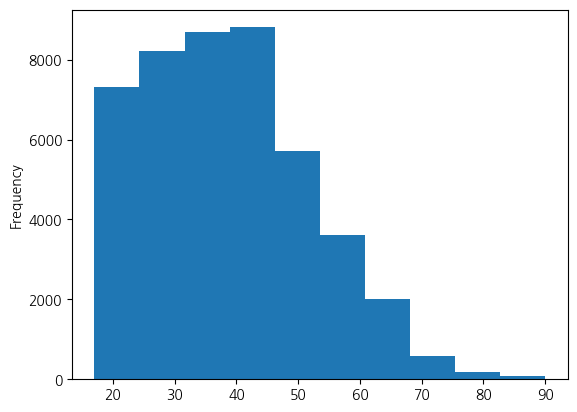


        class
age          
50   0.436671
53   0.404935
51   0.404790
54   0.404110
46   0.403955
..        ...
18   0.000000
82   0.000000
86   0.000000
87   0.000000
89   0.000000

[74 rows x 1 columns]

============================== education-num ==============================
education-num describe count    45222.000000
mean        10.118460
std          2.552881
min          1.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         16.000000
Name: education-num, dtype: float64



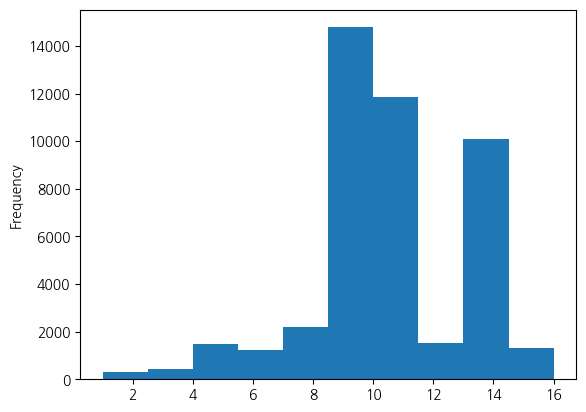


                  class
education-num          
15             0.754140
16             0.733456
14             0.554097
13             0.419815
12             0.264101
11             0.257274
10             0.201030
9              0.163431
8              0.074523
6              0.067048
4              0.066829
5              0.056213
7              0.054972
3              0.048998
2              0.036036
1              0.013889

============================== capital-gain ==============================
capital-gain describe count    45222.000000
mean      1101.430344
std       7506.430084
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64



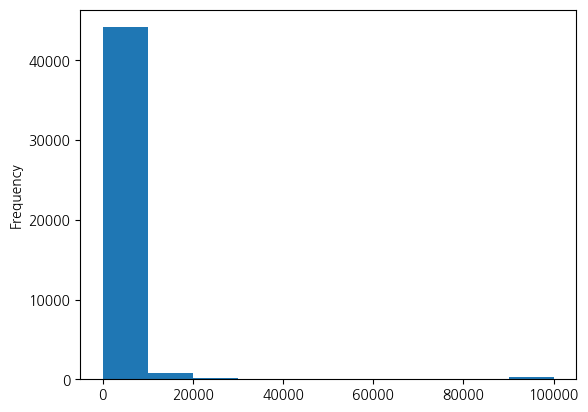


              class
capital-gain       
7298            1.0
10605           1.0
15831           1.0
15024           1.0
15020           1.0
...             ...
7443            0.0
6849            0.0
22040           0.0
34095           0.0
41310           0.0

[121 rows x 1 columns]

============================== capital-loss ==============================
capital-loss describe count    45222.000000
mean        88.595418
std        404.956092
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64



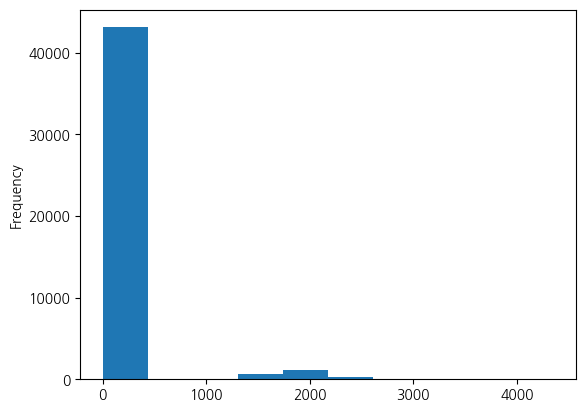


              class
capital-loss       
1564            1.0
2174            1.0
2201            1.0
2231            1.0
2246            1.0
...             ...
2754            0.0
3175            0.0
3770            0.0
3900            0.0
4356            0.0

[97 rows x 1 columns]

============================== hours-per-week ==============================
hours-per-week describe count    45222.000000
mean        40.938017
std         12.007508
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64



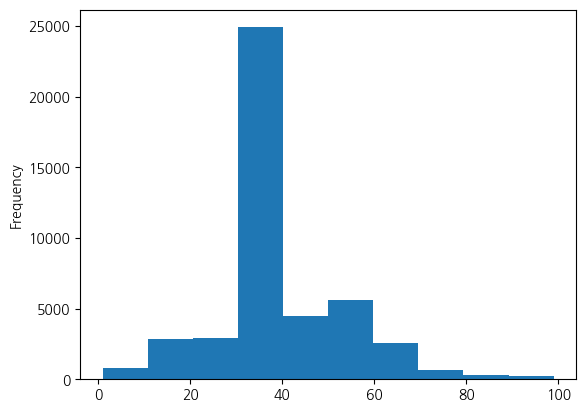


                   class
hours-per-week          
69              1.000000
61              0.750000
76              0.750000
74              0.666667
89              0.666667
...                  ...
82              0.000000
87              0.000000
88              0.000000
94              0.000000
91              0.000000

[96 rows x 1 columns]



In [59]:
for col in num_cols.iloc[:, :-1]:
    print("=" * 30, col, "=" * 30)
    print(col, f"describe {num_cols[col].describe()}")
    print()
    num_cols[col].plot(kind='hist')
    plt.show()
    print()
    print(data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    ratio_result = data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False)
    important_cols.append(ratio_result[ratio_result['class'] > 0.40].index)
    print()

In [60]:
important_cols

[Index([' Self-emp-inc'], dtype='object', name='workclass'),
 Index([' Prof-school', ' Doctorate', ' Masters', ' Bachelors'], dtype='object', name='education'),
 Index([' Married-civ-spouse', ' Married-AF-spouse'], dtype='object', name='marital-status'),
 Index([' Exec-managerial', ' Prof-specialty'], dtype='object', name='occupation'),
 Index([' Wife', ' Husband'], dtype='object', name='relationship'),
 Index([], dtype='object', name='race'),
 Index([], dtype='object', name='sex'),
 Index([' Taiwan', ' France', ' India'], dtype='object', name='native-country'),
 Index([50, 53, 51, 54, 46, 47], dtype='int64', name='age'),
 Index([15, 16, 14, 13], dtype='int64', name='education-num'),
 Index([ 7298, 10605, 15831, 15024, 15020, 14344, 14084, 13550, 11678, 20051,
        25124, 25236, 27828, 99999, 18481,  8614,  9386,  4687,  4787,  5178,
         4934,  6418,  6514,  6097,  5556,  9562, 10520,  7262,  7688,  7430,
         3103,  4386,  7896],
       dtype='int64', name='capital-gain'),

In [61]:
final_cols = []
for col in important_cols:
    if len(col) > 0:
        print(col.name, len(col) )
        final_cols.append(col.name)
#     print(len(col))
final_cols

workclass 1
education 4
marital-status 2
occupation 2
relationship 2
native-country 3
age 6
education-num 4
capital-gain 33
capital-loss 26
hours-per-week 16


['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'native-country',
 'age',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

In [64]:
data['education'].value_counts()

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64

In [65]:
data['education-num'].value_counts()

education-num
9     14783
10     9899
13     7570
14     2514
11     1959
7      1619
12     1507
6      1223
4       823
15      785
5       676
8       577
16      544
3       449
2       222
1        72
Name: count, dtype: int64

In [66]:
data_set1 = data[final_cols]
data_set1 = data_set1.drop("education", axis=1)
data_set1

,workclass,marital-status,occupation,relationship,native-country,age,education-num,capital-gain,capital-loss,hours-per-week
0,Private,Never-married,Machine-op-inspct,Own-child,United-States,25,7,0,0,40
1,Private,Married-civ-spouse,Farming-fishing,Husband,United-States,38,9,0,0,50
2,Local-gov,Married-civ-spouse,Protective-serv,Husband,United-States,28,12,0,0,40
3,Private,Married-civ-spouse,Machine-op-inspct,Husband,United-States,44,10,7688,0,40
4,Private,Never-married,Other-service,Not-in-family,United-States,34,6,0,0,30
...,...,...,...,...,...,...,...,...,...,...
45217,Private,Married-civ-spouse,Tech-support,Wife,United-States,27,12,0,0,38
45218,Private,Married-civ-spouse,Machine-op-inspct,Husband,United-States,40,9,0,0,40
45219,Private,Widowed,Adm-clerical,Unmarried,United-States,58,9,0,0,40
45220,Private,Never-married,Adm-clerical,Own-child,United-States,22,9,0,0,20


In [69]:
X = pd.get_dummies(data_set1, drop_first=True)
X

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,25,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,34,6,0,0,30,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,12,0,0,38,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45218,40,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45219,58,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45220,22,9,0,0,20,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [70]:
y = data['class']
y

0        0
1        0
2        1
3        1
4        0
        ..
45217    0
45218    1
45219    0
45220    0
45221    1
Name: class, Length: 45222, dtype: int64

In [71]:
from sklearn.model_selection import train_test_split

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=10)

In [77]:
X_train

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
1476,43,11,0,0,60,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
34419,41,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
35870,33,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
42980,52,9,0,0,45,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
40581,46,13,0,0,55,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5283,29,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1571,45,11,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
33856,50,13,0,0,40,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
76,43,9,0,0,44,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [78]:
y_train

1476     0
34419    0
35870    0
42980    0
40581    0
        ..
5283     0
1571     0
33856    0
76       0
23680    1
Name: class, Length: 27133, dtype: int64

In [79]:
y_train.value_counts()

class
0    20408
1     6725
Name: count, dtype: int64

In [80]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [81]:
dtc = DecisionTreeClassifier(random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.819669412350047
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     13606
           1       0.64      0.61      0.63      4483

    accuracy                           0.82     18089
   macro avg       0.76      0.75      0.75     18089
weighted avg       0.82      0.82      0.82     18089



# 모델 성능 튜닝 (하이퍼파라미터 튜닝)

In [82]:
for i in range(1, 11):
    dtc = DecisionTreeClassifier(max_depth=i, random_state=10)
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_test)
    print("="*30, f"max_depth: {i}", "="*30)
    print(accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))
    print()

============================== max_depth: 1 ==============================
0.7521698269666648
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     13606
           1       0.00      0.00      0.00      4483

    accuracy                           0.75     18089
   macro avg       0.38      0.50      0.43     18089
weighted avg       0.57      0.75      0.65     18089


============================== max_depth: 2 ==============================
0.8239814251755211
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     13606
           1       0.72      0.47      0.57      4483

    accuracy                           0.82     18089
   macro avg       0.78      0.70      0.73     18089
weighted avg       0.81      0.82      0.81     18089




C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

============================== max_depth: 3 ==============================
0.8384653656918569
              precision    recall  f1-score   support

           0       0.86      0.94      0.90     13606
           1       0.75      0.53      0.62      4483

    accuracy                           0.84     18089
   macro avg       0.80      0.73      0.76     18089
weighted avg       0.83      0.84      0.83     18089


============================== max_depth: 4 ==============================
0.8382995190447233
              precision    recall  f1-score   support

           0       0.86      0.94      0.90     13606
           1       0.74      0.53      0.62      4483

    accuracy                           0.84     18089
   macro avg       0.80      0.73      0.76     18089
weighted avg       0.83      0.84      0.83     18089


============================== max_depth: 5 ==============================
0.8440488694786887
              precision    recall  f1-score   support

       

In [83]:
dtc = DecisionTreeClassifier(max_depth=9, random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8526728951296368
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     13606
           1       0.76      0.59      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.82      0.77      0.79     18089
weighted avg       0.85      0.85      0.85     18089



# 의사결정나무 시각화

In [84]:
from sklearn.tree import plot_tree

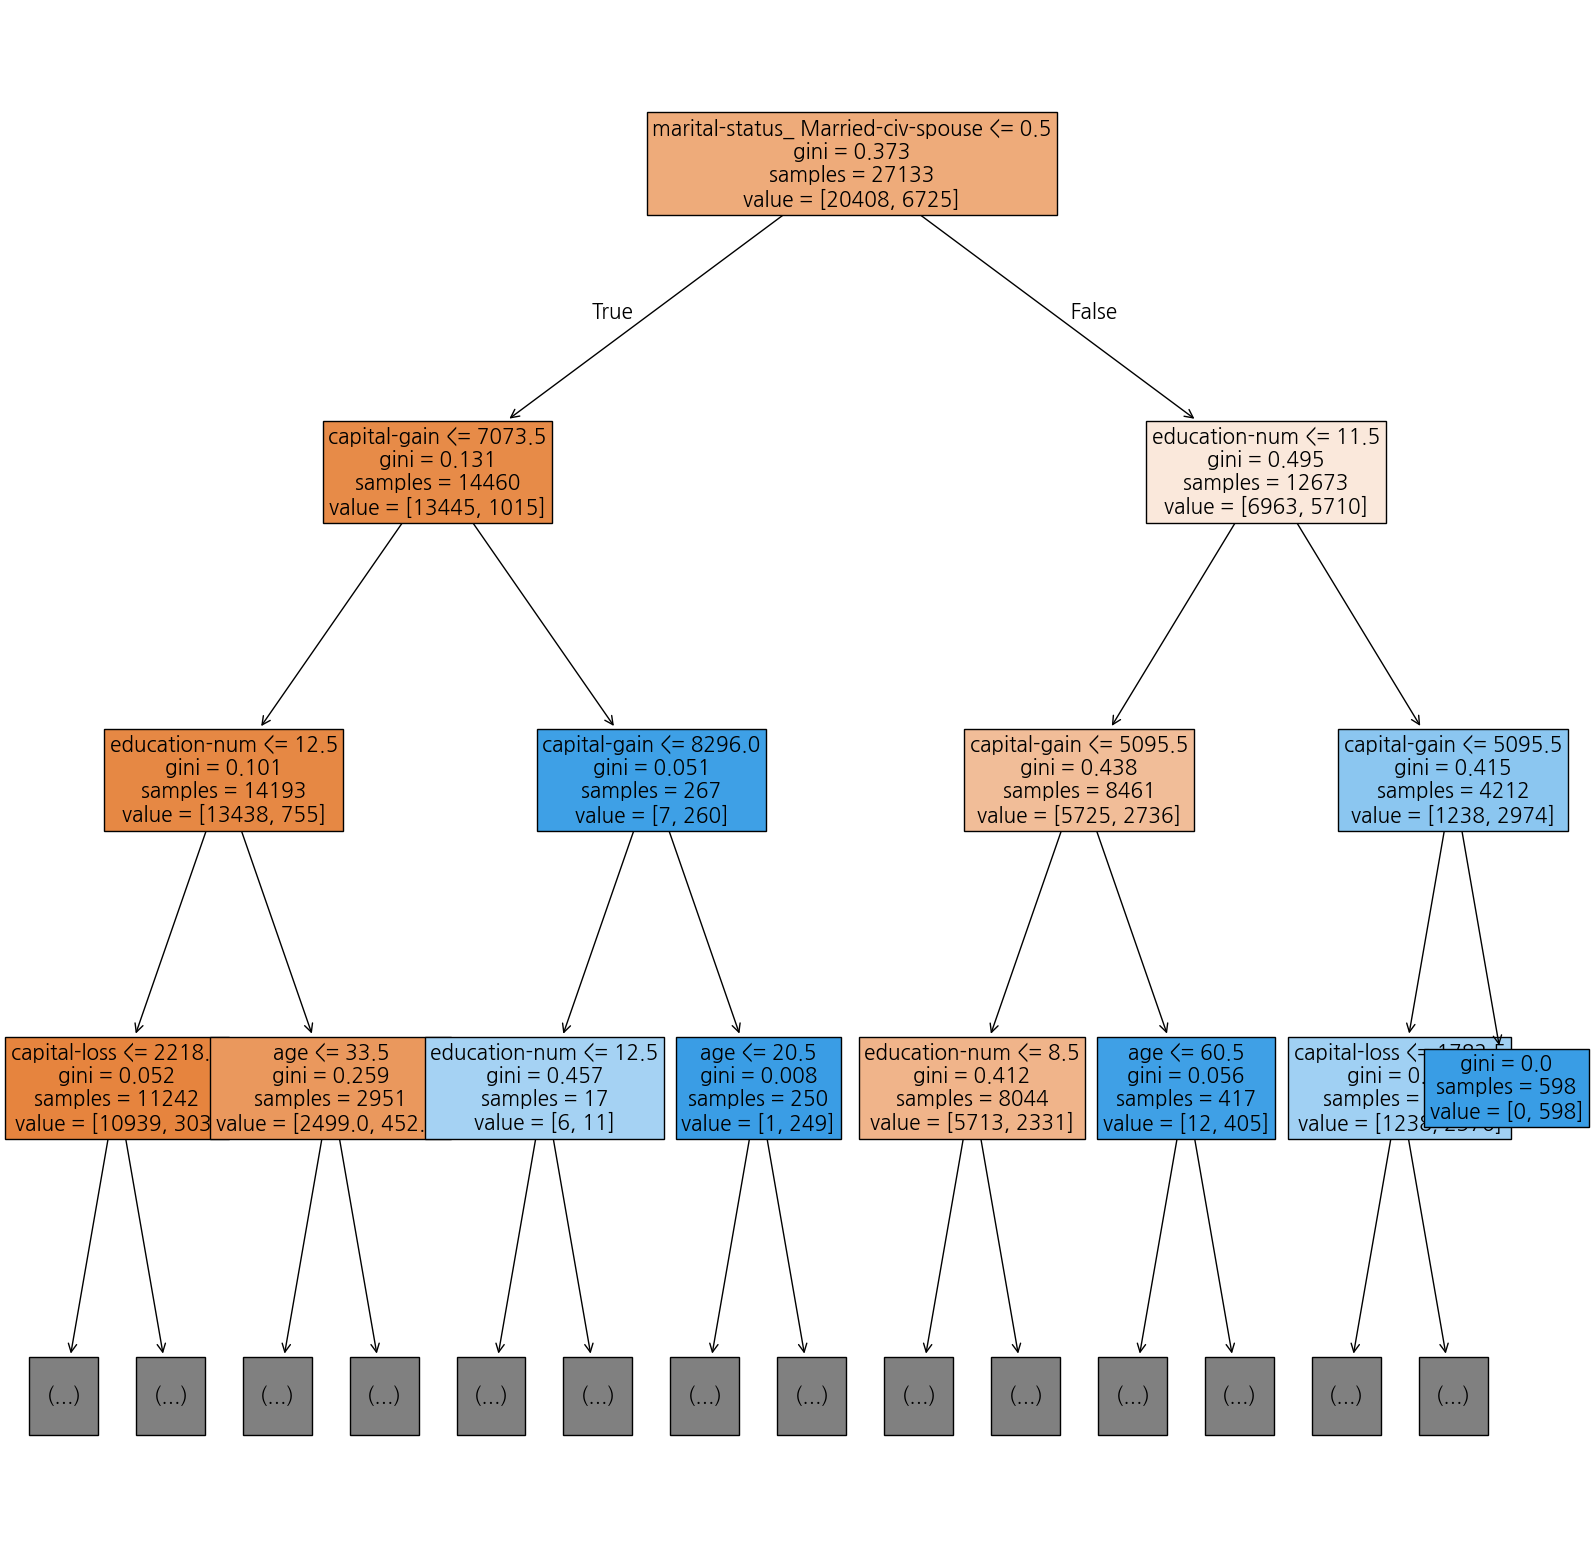

In [86]:
plt.figure(figsize=(20,20))
plot_tree(dtc, feature_names=dtc.feature_names_in_, max_depth=3, fontsize=15, filled=True)
plt.show()